# Identificação de Tweets sobre Desastres Reais — Classificação com NLP

**Competição:** https://www.kaggle.com/competitions/nlp-getting-started  
**Autora:** Juliana Burato  
**Algoritmo:** Word2Vec + Feature Engineering + Ensemble (Soft Voting)  
**F1-Score no Kaggle:** 0.80324

---

## Descrição

Classificação binária de tweets: desastre real (1) ou não (0).  
O dataset contém 7.613 tweets de treino com texto, keyword e localização.

## Fluxo do Projeto

```
train.csv / test.csv
    → Análise Exploratória (EDA)
    → Limpeza e pré-processamento do texto
    → Tokenização + Word2Vec (embeddings 200d, 20 epochs)
    → Feature Engineering (metadados + keyword encoded)
    → Concatenação: embeddings (200d) + features manuais (7d) = vetor de 207 dimensões
    → Avaliação individual: Logistic Regression + Random Forest + SVM
    → Ensemble: Soft Voting dos três modelos
    → submission.csv
```

## 1. Imports

In [1]:
!pip install gensim -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Downloads dos recursos necessários do NLTK
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

# Fixar seed para reprodutibilidade
np.random.seed(42)

print('Imports concluídos.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.4 MB/s eta 0:00:00
Imports concluídos.


## 2. Carregamento dos Dados

Faça upload dos arquivos `train.csv` e `test.csv` diretamente no painel lateral do Colab  
(ícone de pasta → upload) antes de executar a célula abaixo.

Os arquivos estão disponíveis em:  
https://www.kaggle.com/competitions/nlp-getting-started/data

| Arquivo | Linhas | Colunas |
|---|---|---|
| `train.csv` | 7.613 | 5 (id, keyword, location, text, target) |
| `test.csv` | 3.263 | 4 (id, keyword, location, text) |

In [2]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Treino: {train.shape[0]:,} amostras, {train.shape[1]} colunas')
print(f'Teste:  {test.shape[0]:,} amostras, {test.shape[1]} colunas')
train.head()

Treino: 7,613 amostras, 5 colunas
Teste:  3,263 amostras, 4 colunas


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 3. Análise Exploratória (EDA)

Antes de modelar, é importante entender os dados:
- **Balanceamento:** verificar se há desbalanceamento entre as classes (influencia a escolha da métrica)
- **Comprimento dos tweets:** identificar padrões de escrita por classe
- **Keywords:** verificar quais palavras-chave são mais associadas a cada classe
- **Valores ausentes:** identificar colunas com dados faltantes antes do pré-processamento

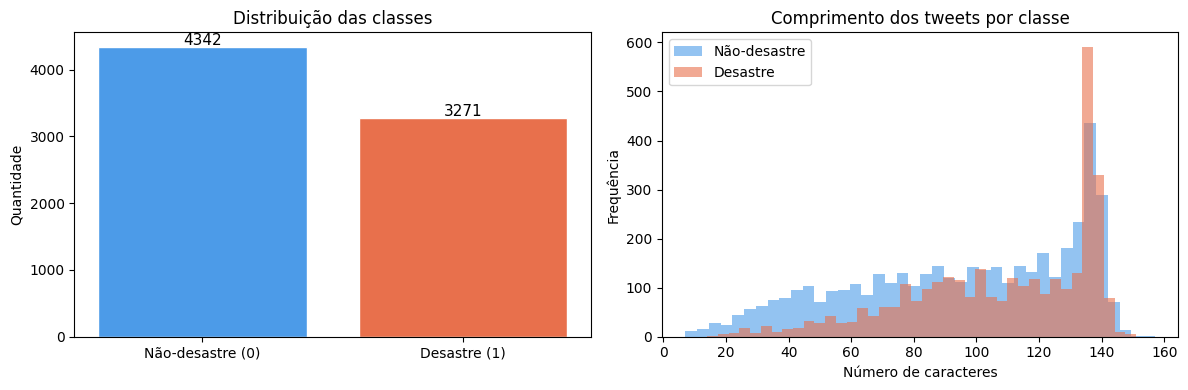

In [3]:
# Distribuição das classes e comprimento dos tweets por classe
# Leve desbalanceamento (43% desastre, 57% não-desastre) — F1-Score é mais adequado que acurácia
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

contagem = train['target'].value_counts()
axes[0].bar(['Não-desastre (0)', 'Desastre (1)'], contagem.values,
            color=['#4C9BE8', '#E8704C'], edgecolor='white')
axes[0].set_title('Distribuição das classes')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=11)

# Tweets de desastre tendem a ser mais longos — será usada como feature
train['text_len'] = train['text'].apply(len)
axes[1].hist(train[train['target']==0]['text_len'], bins=40, alpha=0.6,
             color='#4C9BE8', label='Não-desastre')
axes[1].hist(train[train['target']==1]['text_len'], bins=40, alpha=0.6,
             color='#E8704C', label='Desastre')
axes[1].set_title('Comprimento dos tweets por classe')
axes[1].set_xlabel('Número de caracteres')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

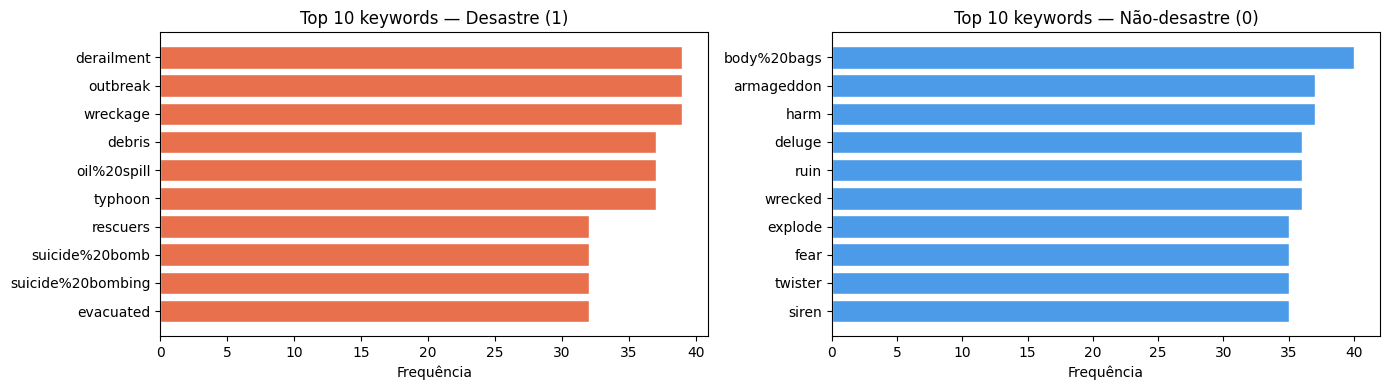

In [4]:
# Keywords mais associadas a cada classe
# A keyword é uma das features mais preditivas — palavras como 'earthquake' e 'flood'
# já indicam fortemente a classe correta
top_desastre     = train[train['target']==1]['keyword'].value_counts().head(10)
top_nao_desastre = train[train['target']==0]['keyword'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(top_desastre.index[::-1], top_desastre.values[::-1],
             color='#E8704C', edgecolor='white')
axes[0].set_title('Top 10 keywords — Desastre (1)')
axes[0].set_xlabel('Frequência')

axes[1].barh(top_nao_desastre.index[::-1], top_nao_desastre.values[::-1],
             color='#4C9BE8', edgecolor='white')
axes[1].set_title('Top 10 keywords — Não-desastre (0)')
axes[1].set_xlabel('Frequência')

plt.tight_layout()
plt.show()

In [5]:
# Verificar valores ausentes
# keyword (61 nulos) e location (2.533 nulos) — text é completo
print('Valores ausentes — treino:')
print(train.isnull().sum())

Valores ausentes — treino:
id             0
keyword       61
location    2533
text           0
target         0
text_len       0
dtype: int64


## 4. Pré-processamento

Etapas aplicadas ao texto de cada tweet:

| Etapa | Descrição | Justificativa |
|---|---|---|
| URLs | Remoção de `http://...` | Não carregam significado semântico |
| Menções | Remoção de `@usuario` | Ruído sem valor preditivo |
| Hashtags | Mantém o texto, remove `#` | O conteúdo da hashtag é relevante |
| Lowercasing | Converte para minúsculas | Unifica tokens (`Fire` = `fire`) |
| Pontuação | Remoção de caracteres especiais | Reduz vocabulário sem perda semântica |
| Stopwords | Remoção de palavras funcionais | Foco em palavras de conteúdo |
| Lematização | Reduz palavras à forma base | `burning → burn`, `fires → fire` |

In [6]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def limpar_texto(texto):
    texto = re.sub(r'http\S+|www\S+', '', texto)        # remove URLs
    texto = re.sub(r'@\w+', '', texto)                   # remove menções
    texto = re.sub(r'#', '', texto)                      # mantém texto das hashtags
    texto = texto.lower()                                # lowercasing
    texto = re.sub(r'[^a-z\s]', '', texto)               # remove pontuação e números
    tokens = word_tokenize(texto)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 2]     # remove stopwords e tokens muito curtos
    return tokens

train['tokens'] = train['text'].apply(limpar_texto)
test['tokens']  = test['text'].apply(limpar_texto)

# Exemplo de tweet antes e depois do pré-processamento
idx = 10
print('Original:', train['text'].iloc[idx])
print('Tokens:  ', train['tokens'].iloc[idx])

Original: Three people died from the heat wave so far
Tokens:   ['three', 'people', 'died', 'heat', 'wave', 'far']


## 5. Feature Engineering

Além dos embeddings Word2Vec, metadados do tweet e a coluna `keyword` são incluídos como features adicionais.  
Essas features capturam padrões que o Word2Vec sozinho não consegue — como urgência, estilo de escrita e o tema central do tweet.

| Feature | Descrição | Hipótese |
|---|---|---|
| `keyword_encoded` | Keyword do tweet (label encoded) | Feature mais preditiva — indica diretamente o tema |
| `text_len` | Número de caracteres | Tweets de desastre tendem a ser mais longos |
| `word_count` | Número de palavras | Mais palavras = mais contexto informativo |
| `hashtag_count` | Número de hashtags | Desastres geram mais hashtags de alerta |
| `url_count` | Número de URLs | Notícias reais costumam ter links |
| `upper_count` | Palavras em maiúsculas | Urgência e alerta são escritos em caps |
| `exclamation_count` | Pontos de exclamação | Indicador de emoção e urgência |

In [7]:
# Preencher nulos da keyword com 'unknown' antes de encodar
train['keyword'] = train['keyword'].fillna('unknown')
test['keyword']  = test['keyword'].fillna('unknown')

# LabelEncoder treinado no corpus completo (treino + teste) para cobrir todos os valores
le = LabelEncoder()
le.fit(pd.concat([train['keyword'], test['keyword']]))
train['keyword_encoded'] = le.transform(train['keyword'])
test['keyword_encoded']  = le.transform(test['keyword'])

def extrair_features(df):
    features = pd.DataFrame()
    features['keyword_encoded']   = df['keyword_encoded']
    features['text_len']          = df['text'].apply(len)
    features['word_count']        = df['text'].apply(lambda x: len(x.split()))
    features['hashtag_count']     = df['text'].apply(lambda x: x.count('#'))
    features['url_count']         = df['text'].apply(lambda x: len(re.findall(r'http\S+', x)))
    features['upper_count']       = df['text'].apply(lambda x: sum(1 for w in x.split() if w.isupper() and len(w) > 1))
    features['exclamation_count'] = df['text'].apply(lambda x: x.count('!'))
    return features.values

features_train = extrair_features(train)
features_test  = extrair_features(test)

print(f'Features manuais — shape: {features_train.shape}')

Features manuais — shape: (7613, 7)


## 6. Word2Vec — Embeddings

Word2Vec aprende representações densas de palavras a partir do contexto em que aparecem.  
Cada tweet é representado pela **média dos vetores** de seus tokens.

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `vector_size` | 200 | Maior capacidade semântica |
| `window` | 5 | Captura contexto local dos tweets |
| `min_count` | 1 | Mantém tokens raros — corpus pequeno, todo token importa |
| `epochs` | 20 | Mais passagens pelo corpus = embeddings mais refinados |
| `sg` | 1 | Skip-gram — melhor para vocabulário pequeno e palavras raras |

> **Nota:** o Word2Vec é treinado em todo o corpus (treino + teste) sem usar os labels,  
> portanto sem data leakage.

In [8]:
# Treinar o Word2Vec em todo o corpus — aproveita mais contexto linguístico sem data leakage
corpus_completo = list(train['tokens']) + list(test['tokens'])

w2v = Word2Vec(
    sentences=corpus_completo,
    vector_size=200,
    window=5,
    min_count=1,
    workers=4,
    sg=1,       # skip-gram — prediz contexto a partir da palavra central
    epochs=20,
    seed=42
)

print(f'Vocabulário: {len(w2v.wv)} palavras')
print('\nPalavras semanticamente próximas de "fire":')
print(w2v.wv.most_similar('fire', topn=5))

Vocabulário: 16076 palavras

Palavras semanticamente próximas de "fire":
[('truck', 0.6521246433258057), ('apartment', 0.5899766683578491), ('forest', 0.5711262822151184), ('township', 0.5572478175163269), ('alarm', 0.5560061931610107)]


In [9]:
def tweet_para_vetor(tokens, modelo):
    # Média dos vetores dos tokens presentes no vocabulário
    # Tweets sem nenhum token no vocabulário retornam vetor zero
    vetores = [modelo.wv[t] for t in tokens if t in modelo.wv]
    if vetores:
        return np.mean(vetores, axis=0)
    return np.zeros(modelo.vector_size)

embeddings_train = np.array([tweet_para_vetor(t, w2v) for t in train['tokens']])
embeddings_test  = np.array([tweet_para_vetor(t, w2v) for t in test['tokens']])

# Concatena embeddings (200d) + features manuais (7d) → vetor final de 207 dimensões
X_train = np.hstack([embeddings_train, features_train])
X_test  = np.hstack([embeddings_test,  features_test])
y       = train['target'].values

print(f'X_train: {X_train.shape}')  # (7613, 207)
print(f'X_test:  {X_test.shape}')   # (3263, 207)

X_train: (7613, 207)
X_test:  (3263, 207)


## 7. Avaliação dos Modelos Individuais

Três classificadores avaliados via cross-validation com 5 folds estratificados.  
O uso de **StratifiedKFold** garante que a proporção das classes seja preservada em cada fold.

Métrica: **F1-Score** — mais adequado que acurácia para classes desbalanceadas,  
pois considera tanto precisão quanto recall.

| Modelo | Vantagem |
|---|---|
| Logistic Regression | Rápido, interpretável, bom baseline linear |
| Random Forest | Captura não-linearidades, robusto a outliers |
| SVM | Eficaz em espaços de alta dimensão como embeddings |

> O `StandardScaler` está dentro de cada `Pipeline` — a normalização é feita  
> apenas nos dados de treino de cada fold, evitando data leakage.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=300, random_state=42))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
    ]),
}

resultados = {}
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y, cv=cv, scoring='f1')
    resultados[nome] = scores
    print(f'{nome:<22} F1: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression    F1: 0.7470 ± 0.0075
Random Forest          F1: 0.7421 ± 0.0139
SVM                    F1: 0.7541 ± 0.0133


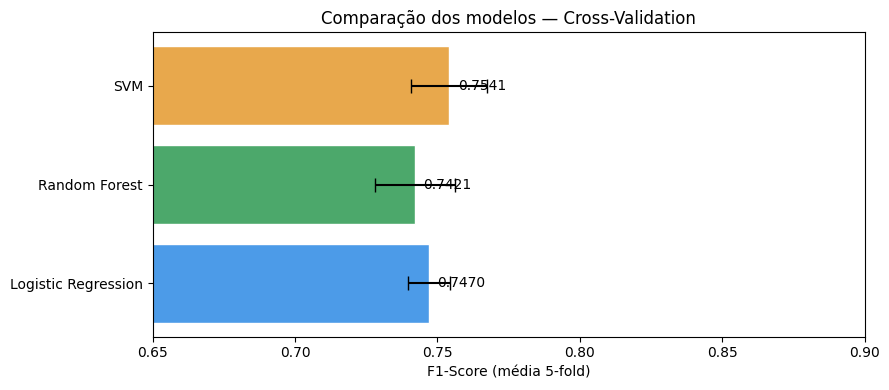

In [11]:
# Comparação visual dos modelos por F1-Score médio e desvio padrão
fig, ax = plt.subplots(figsize=(9, 4))

nomes  = list(resultados.keys())
medias = [resultados[n].mean() for n in nomes]
stds   = [resultados[n].std()  for n in nomes]
cores  = ['#4C9BE8', '#4CA86B', '#E8A84C']

bars = ax.barh(nomes, medias, xerr=stds, color=cores,
               edgecolor='white', capsize=5)
ax.set_xlabel('F1-Score (média 5-fold)')
ax.set_title('Comparação dos modelos — Cross-Validation')
ax.set_xlim(0.65, 0.90)
for bar, media in zip(bars, medias):
    ax.text(media + 0.003, bar.get_y() + bar.get_height()/2,
            f'{media:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Ensemble — Soft Voting

O `VotingClassifier` combina as previsões dos três modelos por votação suave (soft voting).

| Estratégia | Descrição |
|---|---|
| Hard voting | Cada modelo vota 0 ou 1 — vence a maioria |
| **Soft voting** | Média das probabilidades de cada modelo — mais estável e geralmente superior |

In [12]:
ensemble = VotingClassifier(
    estimators=[
        ('lr',  Pipeline([('scaler', StandardScaler()),
                          ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=42))])),
        ('rf',  Pipeline([('scaler', StandardScaler()),
                          ('clf', RandomForestClassifier(n_estimators=300, random_state=42))])),
        ('svm', Pipeline([('scaler', StandardScaler()),
                          ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))])),
    ],
    voting='soft'
)

scores_ensemble = cross_val_score(ensemble, X_train, y, cv=cv, scoring='f1')
print(f'Ensemble (Soft Voting)  F1: {scores_ensemble.mean():.4f} ± {scores_ensemble.std():.4f}')

# Comparação com o melhor modelo individual
melhor_individual = max(resultados, key=lambda n: resultados[n].mean())
print(f'\nMelhor modelo individual ({melhor_individual}): {resultados[melhor_individual].mean():.4f}')
print(f'Ensemble:                                       {scores_ensemble.mean():.4f}')

Ensemble (Soft Voting)  F1: 0.7562 ± 0.0136

Melhor modelo individual (SVM): 0.7541
Ensemble:                                       0.7562


## 9. Avaliação Final

Avaliação do ensemble em um conjunto de validação separado:
1. **Relatório por classe:** precisão, recall e F1-Score para cada classe
2. **Matriz de confusão:** identificar erros sistemáticos entre as classes

In [13]:
# Divisão estratificada treino/validação — preserva a proporção das classes
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y, test_size=0.2, random_state=42, stratify=y
)

ensemble.fit(X_tr, y_tr)
y_pred = ensemble.predict(X_val)

print(f'F1-Score (validação): {f1_score(y_val, y_pred):.4f}')
print()
print(classification_report(y_val, y_pred,
                             target_names=['Não-desastre', 'Desastre']))

F1-Score (validação): 0.7719

              precision    recall  f1-score   support

Não-desastre       0.81      0.89      0.85       869
    Desastre       0.83      0.72      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.81      0.81      1523
weighted avg       0.82      0.82      0.81      1523



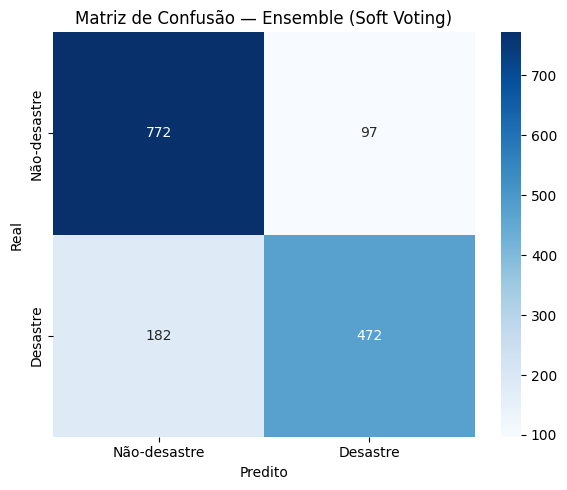

In [14]:
# Matriz de confusão
# Erros simétricos entre as classes indicam que o modelo não tem viés por classe
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não-desastre', 'Desastre'],
            yticklabels=['Não-desastre', 'Desastre'])
plt.title('Matriz de Confusão — Ensemble (Soft Voting)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.tight_layout()
plt.show()

## 10. Submissão

Para a submissão final, o ensemble é retreinado com **todos os 7.613 exemplos** de treino,  
maximizando a quantidade de dados disponíveis para o modelo aprender.

In [15]:
# Retreinar no conjunto completo antes de gerar as previsões finais
ensemble.fit(X_train, y)
predicoes = ensemble.predict(X_test)

submission = pd.DataFrame({
    'id':     test['id'],
    'target': predicoes
})
submission.to_csv('submission.csv', index=False)

print(f'submission.csv gerado com {len(submission):,} previsões')
print(submission['target'].value_counts().to_string())

submission.csv gerado com 3,263 previsões
target
0    2086
1    1177


## 11. Conclusão

O modelo ensemble com Soft Voting atingiu **F1-Score de 0,803** no Kaggle,  
demonstrando que a combinação de embeddings semânticos com features estruturais do tweet  
é uma abordagem eficaz para classificação de texto em domínios específicos.

Os principais fatores que contribuíram para o resultado:

- **Word2Vec (Skip-gram, 200d):** embeddings treinados no corpus completo capturam relações semânticas específicas do domínio de desastres
- **Feature Engineering:** metadados como `keyword_encoded`, comprimento do tweet e contagem de maiúsculas adicionam informação estrutural que os embeddings não capturam
- **Soft Voting:** a combinação dos três modelos (Logistic Regression, Random Forest e SVM) foi mais robusta do que qualquer modelo individual
- **Pipeline com StandardScaler:** a normalização dentro de cada fold do cross-validation garantiu avaliação sem data leakage